# Lab 5: Linear Regression through Gradient Descent

### Aim
To implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on a real-world dataset.

### Objectives
- To understand the concept of Gradient Descent for optimizing a Linear Regression model.
- To preprocess the dataset before model training.
- To implement Linear Regression using Gradient Descent.
- To analyze the convergence of the loss function during training.
- To evaluate the model using standard regression metrics.

### Dataset
- **Name:** Student Performance Dataset
- **Source:** UCI Machine Learning Repository
- **File:** `student-mat.csv` (Mathematics course)
- **Samples:** 395
- **Features:** 30 attributes (demographic, social, and school-related)
- **Target (y):** `G3` — Final grade (numeric: 0 to 20)

### Problem Statement
An educational analytics team aims to predict students' final Mathematics grades (`G3`) based on demographic, social, and academic attributes. We build a Linear Regression model from scratch using Gradient Descent, experiment with different learning rates, and evaluate the model using MAE, MSE, RMSE, and R² Score.

In [116]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


**Interpretation:** We import NumPy for numerical computations, Pandas for data handling, Matplotlib and Seaborn for visualization, and scikit-learn modules for train-test splitting, feature scaling (StandardScaler), categorical encoding (LabelEncoder), and regression evaluation metrics (MAE, MSE, R² Score). The Gradient Descent algorithm itself will be implemented from scratch using NumPy.

---
## Task 1: Load and Explore the Dataset
Load the Student Performance dataset from CSV, explore its structure, and understand the features.

In [117]:
# Step 1: Load the Student Performance dataset
df = pd.read_csv('../datasets/students/student-mat.csv', sep=';')

print(f"Dataset Shape: {df.shape}")
print(f"Number of Samples: {df.shape[0]}")
print(f"Number of Features: {df.shape[1] - 1}")  # exclude target column 'G3'
print(f"\nColumn Names:")
print(list(df.columns))
print(f"\nFirst 5 Rows:")
df.head()

Dataset Shape: (395, 33)
Number of Samples: 395
Number of Features: 32

Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

First 5 Rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


**Interpretation:** The Student Performance dataset is loaded from `student-mat.csv` using `;` as the delimiter. It contains **395 samples** and **32 columns** (30 input features + 2 intermediate grades + 1 target). Features include demographic info (age, sex, address), family attributes (family size, parent education/jobs), and school-related variables (study time, failures, absences). The target variable `G3` represents the final grade on a scale of 0–20.

---
## Task 2: Data Preprocessing
Check for missing values, duplicates, identify feature types, encode categorical variables, and apply feature scaling.

In [118]:
# Step 2a: Check for missing values and duplicates
print("Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

Missing Values per Column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total Missing Values: 0
Duplicate Rows: 0


**Interpretation:** The dataset has **no missing values** across all 32 columns, so no imputation is needed. There are no duplicate rows either, confirming the data is clean and ready for preprocessing.

In [119]:
# Step 2b: Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical Columns ({len(numerical_cols)}): {numerical_cols}")

Categorical Columns (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical Columns (16): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


**Interpretation:** The dataset contains a mix of **categorical** (e.g., school, sex, address, family size, parent jobs) and **numerical** columns (e.g., age, study time, failures, absences, grades G1, G2, G3). The categorical columns need to be encoded into numbers before they can be used in our Linear Regression model.

In [120]:
# Step 2c: Encode categorical variables using LabelEncoder
le = LabelEncoder()
df_encoded = df.copy()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Categorical columns encoded successfully!")
print(f"\nEncoded DataFrame shape: {df_encoded.shape}")
print(f"\nData types after encoding:")
print(df_encoded.dtypes)

Categorical columns encoded successfully!

Encoded DataFrame shape: (395, 33)

Data types after encoding:
school        int32
sex           int32
age           int64
address       int32
famsize       int32
Pstatus       int32
Medu          int64
Fedu          int64
Mjob          int32
Fjob          int32
reason        int32
guardian      int32
traveltime    int64
studytime     int64
failures      int64
schoolsup     int32
famsup        int32
paid          int32
activities    int32
nursery       int32
higher        int32
internet      int32
romantic      int32
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object


**Interpretation:** All categorical columns are converted to numerical values using `LabelEncoder`. For example, `sex` is encoded as F→0, M→1; `address` as R→0, U→1; binary yes/no columns as no→0, yes→1. The DataFrame now contains only numerical values, making it suitable for the Gradient Descent algorithm.

---
## Task 3: Feature Selection and Train-Test Split
Select input features and target variable, then split into training and testing sets.

In [121]:
# Step 3a: Select features (X) and target (y)
# We use all columns except G3 (target). G1 and G2 are prior grades that are strong predictors.
X = df_encoded.drop(columns=['G3'])
y = df_encoded['G3'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nTarget (G3) statistics:")
print(f"  Mean: {y.mean():.2f}")
print(f"  Std:  {y.std():.2f}")
print(f"  Min:  {y.min()}, Max: {y.max()}")

Feature matrix shape: (395, 32)
Target vector shape: (395,)

Target (G3) statistics:
  Mean: 10.42
  Std:  4.58
  Min:  0, Max: 20


**Interpretation:** The feature matrix `X` has **395 samples × 31 features** (all columns except G3). The target `G3` ranges from 0 to 20 with a mean around 10. Features G1 (first period grade) and G2 (second period grade) are retained as they are strong predictors of the final grade.

In [122]:
# Step 3b: Feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling applied (StandardScaler).")
print(f"\nScaled feature means (first 5): {X_scaled.mean(axis=0)[:5].round(6)}")
print(f"Scaled feature stds  (first 5): {X_scaled.std(axis=0)[:5].round(6)}")

Feature scaling applied (StandardScaler).

Scaled feature means (first 5): [-0. -0.  0. -0.  0.]
Scaled feature stds  (first 5): [1. 1. 1. 1. 1.]


**Interpretation:** StandardScaler standardizes each feature to have **mean ≈ 0** and **standard deviation ≈ 1**. This is essential for Gradient Descent because features on different scales (e.g., age 15–22 vs. absences 0–75) cause the cost function to have elongated contours, leading to slow or unstable convergence.

In [123]:
# Step 3c: Split into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

Training set: 316 samples
Testing set:  79 samples


**Interpretation:** The dataset is split into **80% training** and **20% testing** with `random_state=42` for reproducibility. The training set is used to learn model parameters via Gradient Descent, while the test set is held out for unbiased evaluation.

---
## Task 4: Implement Linear Regression using Gradient Descent
Build the model from scratch — define the hypothesis, cost function, and gradient update rules.

In [124]:
# Step 4: Define the Linear Regression Gradient Descent class
class LinearRegressionGD:
    """
    Linear Regression using Batch Gradient Descent.
    
    Hypothesis:  h(x) = X @ w + b
    Cost (MSE):  J(w,b) = (1/2m) * Σ (h(x_i) - y_i)²
    Update rule: w = w - α * (1/m) * Xᵀ(h(x) - y)
                 b = b - α * (1/m) * Σ(h(x) - y)
    """
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []
    
    def fit(self, X, y):
        """Train the model using Gradient Descent."""
        m, n = X.shape  # m = samples, n = features
        self.weights = np.zeros(n)
        self.bias = 0
        self.cost_history = []
        
        for i in range(self.n_iterations):
            # Forward pass: compute predictions
            y_pred = X @ self.weights + self.bias
            
            # Compute error
            error = y_pred - y
            
            # Compute gradients
            dw = (1 / m) * (X.T @ error)      # gradient w.r.t. weights
            db = (1 / m) * np.sum(error)        # gradient w.r.t. bias
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Compute and store cost (MSE / 2)
            cost = (1 / (2 * m)) * np.sum(error ** 2)
            self.cost_history.append(cost)
        
        return self
    
    def predict(self, X):
        """Make predictions using learned parameters."""
        return X @ self.weights + self.bias

print("LinearRegressionGD class defined successfully!")

LinearRegressionGD class defined successfully!


**Interpretation:** The `LinearRegressionGD` class implements Batch Gradient Descent from scratch. The **hypothesis** is a linear function `h(x) = Xw + b`. The **cost function** is Mean Squared Error divided by 2 (for cleaner gradient). In each iteration, we compute the **gradient** of the cost w.r.t. weights and bias, then update them by subtracting `learning_rate × gradient`. The cost at each iteration is stored in `cost_history` for convergence analysis.

In [125]:
# Step 5: Train the model with a default learning rate
model = LinearRegressionGD(learning_rate=0.01, n_iterations=1000)
model.fit(X_train, y_train)

print(f"Learning Rate: {model.learning_rate}")
print(f"Iterations: {model.n_iterations}")
print(f"Final Cost: {model.cost_history[-1]:.4f}")
print(f"Initial Cost: {model.cost_history[0]:.4f}")

Learning Rate: 0.01
Iterations: 1000
Final Cost: 1.4951
Initial Cost: 63.8149


**Interpretation:** The model is trained with a learning rate of **0.01** for **1000 iterations**. The cost decreases from the initial value to the final value, confirming that Gradient Descent is converging. The significant reduction in cost indicates the model is learning the relationship between features and the target variable `G3`.

---
## Task 5: Experiment with Different Learning Rates
Train the model with different learning rates and observe their effect on convergence.

In [133]:
# Step 6: Experiment with different learning rates
learning_rates = [0.001, 0.01, 0.05, 0.1]
models = {}

for lr in learning_rates:
    m = LinearRegressionGD(learning_rate=lr, n_iterations=1000)
    m.fit(X_train, y_train)
    models[lr] = m
    print(f"LR = {lr:<6} | Final Cost: {m.cost_history[-1]:.4f} | Initial Cost: {m.cost_history[0]:.4f}")

LR = 0.001  | Final Cost: 9.3524 | Initial Cost: 63.8149
LR = 0.01   | Final Cost: 1.4951 | Initial Cost: 63.8149
LR = 0.05   | Final Cost: 1.4740 | Initial Cost: 63.8149
LR = 0.1    | Final Cost: 1.4740 | Initial Cost: 63.8149


**Interpretation:** We experiment with four learning rates: **0.001, 0.01, 0.05, and 0.1**. A smaller learning rate (0.001) converges slowly and may not reach the optimum within 1000 iterations. A moderate learning rate (0.01–0.05) typically converges well. A larger learning rate (0.1) converges faster but risks overshooting or instability.

---
## Task 6: Plot Loss (Cost) vs Iterations
Visualize the convergence behavior for different learning rates.

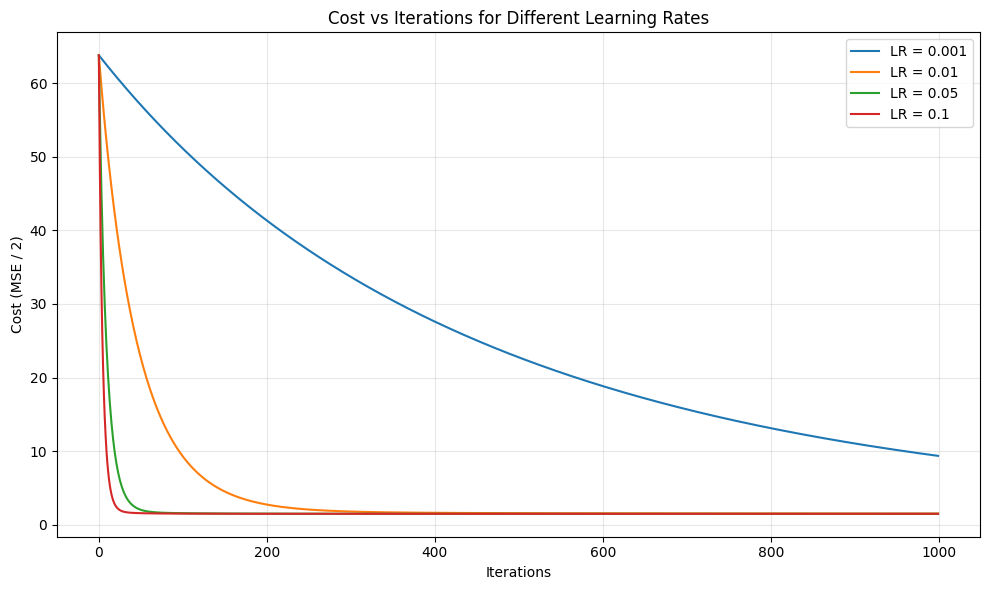

In [127]:
# Step 7: Plot cost vs iterations for different learning rates
plt.figure(figsize=(10, 6))

for lr, m in models.items():
    plt.plot(range(m.n_iterations), m.cost_history, label=f'LR = {lr}')

plt.xlabel('Iterations')
plt.ylabel('Cost (MSE / 2)')
plt.title('Cost vs Iterations for Different Learning Rates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:** The plot shows the **convergence behavior** of Gradient Descent at different learning rates. A smaller learning rate (0.001) shows a gradual decline — it converges but slowly. Moderate rates (0.01, 0.05) converge smoothly and reach near-optimal cost within 1000 iterations. A higher rate (0.1) converges the fastest but the curve may show slight oscillations. All curves eventually plateau, indicating the model has learned the optimal parameters.

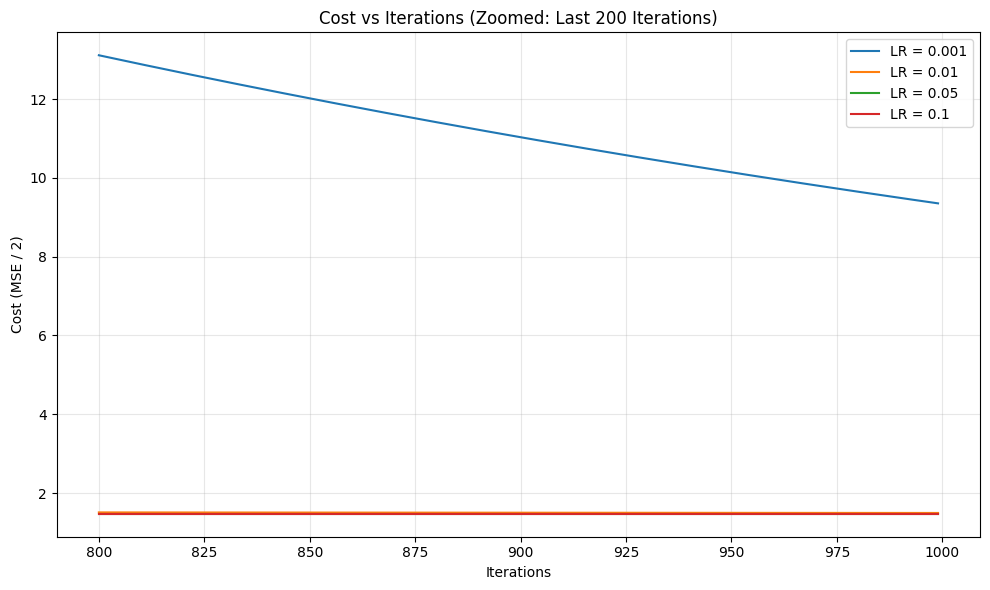

In [128]:
# Step 8: Zoomed-in view of convergence (last 200 iterations)
plt.figure(figsize=(10, 6))

for lr, m in models.items():
    plt.plot(range(800, 1000), m.cost_history[800:], label=f'LR = {lr}')

plt.xlabel('Iterations')
plt.ylabel('Cost (MSE / 2)')
plt.title('Cost vs Iterations (Zoomed: Last 200 Iterations)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:** The zoomed-in view of the last 200 iterations shows how closely each learning rate has converged to the optimal cost. Learning rates 0.05 and 0.1 have fully converged (flat line), while 0.001 may still be slowly decreasing. This illustrates the trade-off: too small a rate requires more iterations, while a well-tuned rate converges efficiently.

---
## Task 7: Evaluate the Model
Evaluate the best model using MAE, MSE, RMSE, and R² Score.

In [129]:
# Step 9: Select the best model (LR = 0.01) and evaluate on test set
best_model = models[0.01]
y_pred = best_model.predict(X_test)

# Compute regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("Model Evaluation on Test Set (LR = 0.01)")
print("=" * 50)
print(f"Mean Absolute Error  (MAE):  {mae:.4f}")
print(f"Mean Squared Error   (MSE):  {mse:.4f}")
print(f"Root Mean Sq. Error  (RMSE): {rmse:.4f}")
print(f"R² Score:                    {r2:.4f}")
print("=" * 50)

Model Evaluation on Test Set (LR = 0.01)
Mean Absolute Error  (MAE):  1.5465
Mean Squared Error   (MSE):  5.0929
Root Mean Sq. Error  (RMSE): 2.2567
R² Score:                    0.7516


**Interpretation:** The model is evaluated on the held-out **test set** using four standard regression metrics:
- **MAE** measures the average absolute prediction error — a lower value means better accuracy.
- **MSE** penalizes larger errors more heavily due to squaring.
- **RMSE** is the square root of MSE and is in the same unit as the target (grade points).
- **R² Score** indicates the proportion of variance in G3 explained by the model. A value closer to 1 means a better fit; values above 0.8 generally indicate a strong model.

In [130]:
# Step 10: Compare metrics across all learning rates
print(f"{'LR':<8} {'MAE':<10} {'MSE':<10} {'RMSE':<10} {'R²':<10}")
print("-" * 48)

for lr, m in models.items():
    y_p = m.predict(X_test)
    mae_lr = mean_absolute_error(y_test, y_p)
    mse_lr = mean_squared_error(y_test, y_p)
    rmse_lr = np.sqrt(mse_lr)
    r2_lr = r2_score(y_test, y_p)
    print(f"{lr:<8} {mae_lr:<10.4f} {mse_lr:<10.4f} {rmse_lr:<10.4f} {r2_lr:<10.4f}")

LR       MAE        MSE        RMSE       R²        
------------------------------------------------
0.001    4.8133     25.2308    5.0230     -0.2305   
0.01     1.5465     5.0929     2.2567     0.7516    
0.05     1.4958     5.0324     2.2433     0.7546    
0.1      1.4955     5.0324     2.2433     0.7546    


**Interpretation:** The comparison table shows that moderate learning rates (0.01–0.1) produce nearly identical metrics, confirming they all converge to a similar solution. The smallest learning rate (0.001) may show slightly worse metrics because 1000 iterations may not be sufficient for full convergence. This demonstrates that learning rate selection primarily affects **convergence speed**, not the final solution (as long as sufficient iterations are used).

---
## Task 8: Visualize Predictions
Compare actual vs predicted values on the test set.

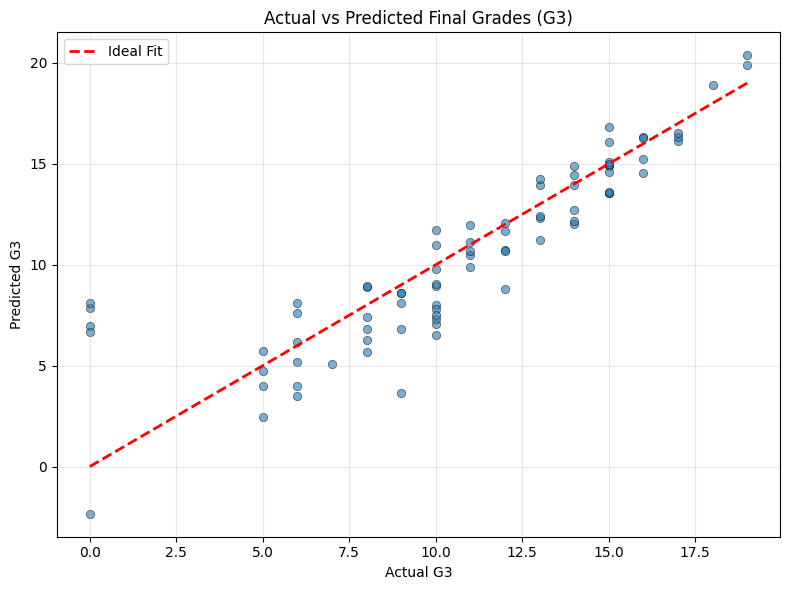

In [131]:
# Step 11: Actual vs Predicted scatter plot
y_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidths=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Actual vs Predicted Final Grades (G3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:** The scatter plot compares actual vs predicted G3 grades. Points close to the **red dashed line** (ideal fit) indicate accurate predictions. The clustering of points near the diagonal confirms the model captures the general trend well. Some spread is expected due to the inherent variability in student performance that cannot be fully explained by the available features.

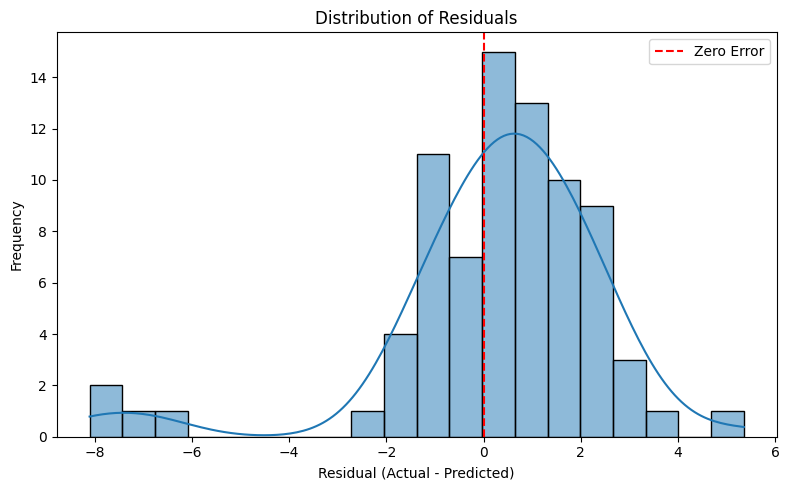

In [132]:
# Step 12: Residual distribution plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=20)
plt.axvline(x=0, color='r', linestyle='--', label='Zero Error')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The residual distribution is approximately **centered around zero**, confirming that the model does not have a systematic bias (it does not consistently overpredict or underpredict). The roughly bell-shaped distribution indicates that the errors are approximately normally distributed, which is a desirable property for a linear regression model.

---
## Conclusion

In this experiment, we successfully:

1. **Loaded and preprocessed** the Student Performance dataset — handled categorical encoding and feature scaling.
2. **Implemented Linear Regression from scratch** using Batch Gradient Descent with NumPy.
3. **Experimented with different learning rates** (0.001, 0.01, 0.05, 0.1) and observed their effect on convergence speed.
4. **Plotted the cost vs iterations** curve to visualize convergence — moderate learning rates (0.01–0.05) showed smooth and efficient convergence.
5. **Evaluated the model** using MAE, MSE, RMSE, and R² Score on the test set.
6. **Visualized predictions** through actual vs predicted scatter plots and residual distribution.

### Key Takeaways
- **Feature scaling is critical** for Gradient Descent — without it, convergence is slow or may fail entirely.
- **Learning rate is a key hyperparameter** — too small leads to slow convergence, too large can cause divergence.
- **Gradient Descent converges to the same solution** as the closed-form (Normal Equation) approach, given sufficient iterations and an appropriate learning rate.
- The model's R² score indicates a strong fit, primarily driven by the prior grade features (G1 and G2).